In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

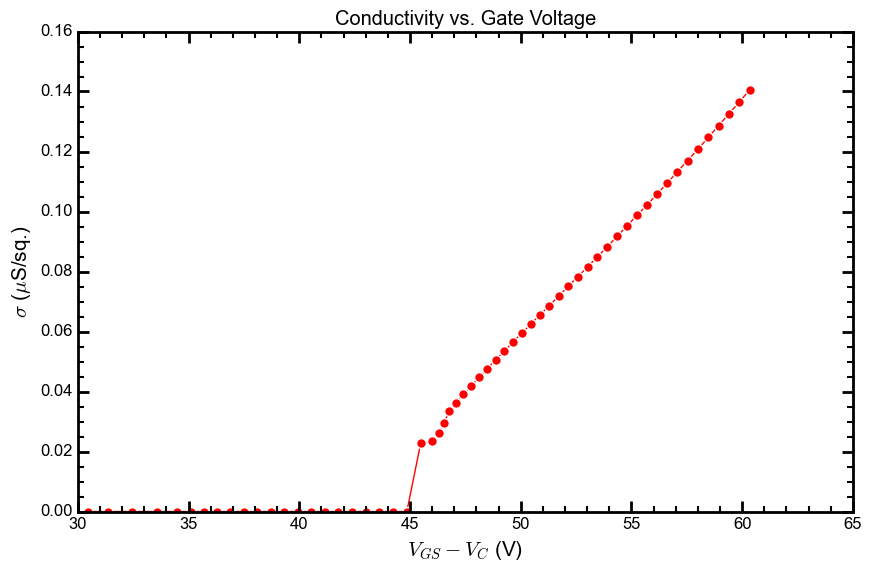

In [56]:
data = np.loadtxt("./Data-20261006/02.dat")

V_GS = data[:, 0]
I_DS = data[:, 1]
V_DS = data[:, 2]
V_C = 0.5 * (data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = -data[:, 7]
V_del = -(V_GS - V_C)

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    markeredgecolor="white", markeredgewidth=1, markersize=7
    )

plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage")
plt.show()

C = 1.8e-9
A = 32e-6
Ci = C / A

Mobility (μ): 1.38 cm^2/Vs
Threshold Voltage (V_T): 42.42 V


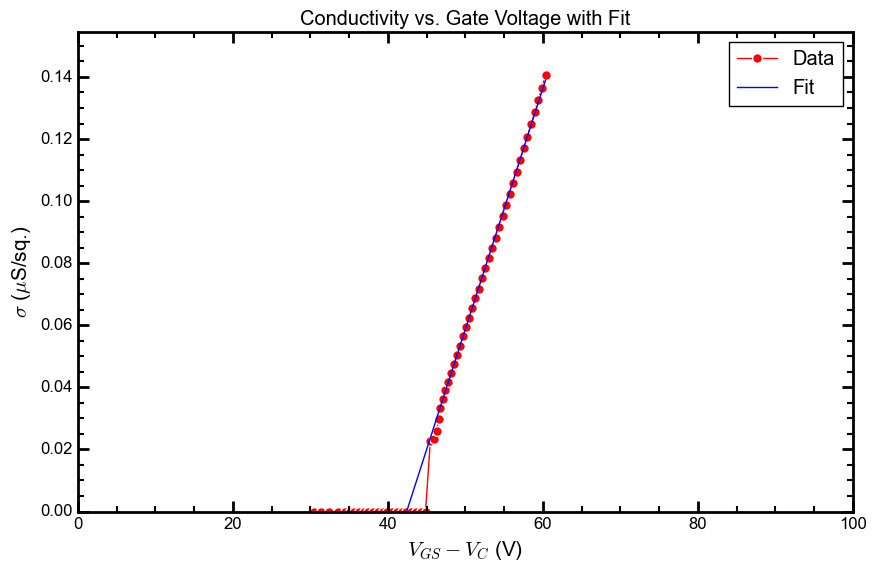

In [57]:
def func(x, a, b):
    return a*x + b

mask = (V_del > 47)  


popt, pcov = curve_fit(func, V_del[mask], sigma[mask])
sigma_fit = func(V_del, *popt)
a = popt[0]
b = popt[1]

mu = a / Ci * 1e4
V_T = -b / a

print(f"Mobility (μ): {mu:.2f} cm^2/Vs")
print(f"Threshold Voltage (V_T): {V_T:.2f} V")



# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    label='Data',
    markeredgecolor="white", markeredgewidth=1, markersize=7
    )
plt.plot(
    V_del,
    sigma_fit * 1e6,
    color='blue',
    ls='-',
    label=f'Fit'
    )
plt.xlabel(r"$V_{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage with Fit")
plt.xlim(0,100)
plt.ylim(0, sigma.max() * 1e6 * 1.1)  # Convert to μS/sq. for y-axis limits
plt.legend(numpoints=1)
plt.show()


